In [1]:
import torch
import torch.nn as nn

import torch_geometric as tg
import torch_geometric.utils as tgu
import torch_geometric.nn as tgnn
import matplotlib.pyplot as plt

import numpy as np

## Notes from graphcast
 - there are multiple layers of nodes -> some nodes propagate information to more distant nodes
 - loss function takes into account multiple factors - e.g. sample density
 - autoregressive training 
   - model is trained using fix interval
   - to predict more distant (in time) points then previous prediction of a model is used
   - predicting 10 day ahead tends to have large overfitting
 - gnn was selected because weather function is the same in every place of the globe

In [2]:
omega = 1.8

feature_vec_len = 8
x = np.arange(0,6.4,0.1).reshape((-1,1))
t = np.arange(0,6,0.1).reshape([-1,1])

values = np.sin(omega*t+x.T)

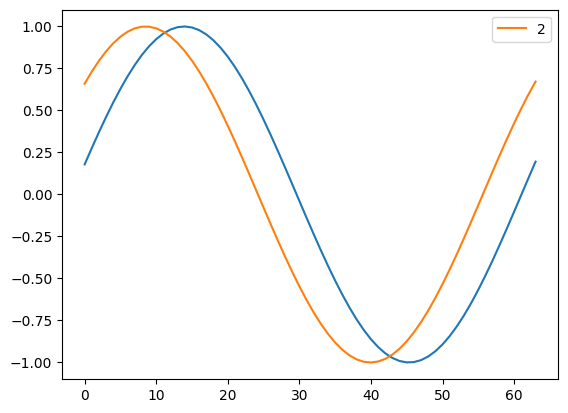

In [3]:
plt.plot(values[1,:])
plt.plot(values[4,:], label='2')
plt.legend()

In [4]:
def get_sample(values, dt=4, inclusion_prob=0.5):
    time_horizon, positions = values.shape

    fully_connected_adj = torch.ones(positions, positions)
    fully_connected = tgu.dense_to_sparse(fully_connected_adj)[0]

    sample = []
    sample_dt = []

    time_stamp = np.random.randint(time_horizon - dt)

    is_included = np.random.random(positions) < inclusion_prob
    for idx, included in zip(range(positions), is_included):
        sample.append((
            idx/positions,
            included*1.0,
            values[time_stamp, idx] * included,
        ))
        sample_dt.append((
            idx/positions,
            1.0,
            values[time_stamp + dt, idx],
        ))

    return (
        torch.tensor(sample, dtype=torch.float32, requires_grad=False),
        torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),
        torch.tensor(sample_dt, dtype=torch.float32, requires_grad=False)
    )

In [5]:
class feature_encoder(nn.Module):
    def __init__(self, dims=None, output_feature_num=feature_vec_len):
        nn.Module.__init__(self)

        if dims is None:
            self.dims = {
                "time": 1,
                "x_pos": 1,
                "value": 1,
            } 
        else:
            self.dims = dims

        self.input_dimensionality = sum(self.dims.values())

        self.seq = nn.Sequential(
            nn.Linear(self.input_dimensionality, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU(),
            nn.Linear(32, output_feature_num),
            nn.Tanh()
        )

    def forward(self, x):
        return self.seq(x)

In [6]:
fe_model = feature_encoder()
te = feature_encoder({'time': 1}, output_feature_num=16)
sample = get_sample(values)
fe_model(sample[0])

/tmp/ipykernel_449/3835534236.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


tensor([[ 0.0777, -0.1696, -0.1208, -0.2202, -0.0460,  0.0526,  0.1086,  0.2176],
        [ 0.0784, -0.1712, -0.1219, -0.2205, -0.0472,  0.0530,  0.1092,  0.2185],
        [ 0.0021, -0.1536, -0.0863, -0.1759, -0.0271,  0.1090,  0.0745,  0.1271],
        [ 0.0024, -0.1542, -0.0870, -0.1753, -0.0285,  0.1093,  0.0743,  0.1261],
        [ 0.0798, -0.1730, -0.1224, -0.2176, -0.0492,  0.0541,  0.1102,  0.2167],
        [ 0.0799, -0.1726, -0.1216, -0.2154, -0.0494,  0.0545,  0.1102,  0.2147],
        [ 0.0798, -0.1716, -0.1204, -0.2127, -0.0493,  0.0550,  0.1099,  0.2119],
        [ 0.0034, -0.1568, -0.0899, -0.1730, -0.0342,  0.1107,  0.0731,  0.1224],
        [ 0.0037, -0.1575, -0.0906, -0.1725, -0.0357,  0.1110,  0.0728,  0.1215],
        [ 0.0781, -0.1662, -0.1146, -0.2016, -0.0478,  0.0569,  0.1079,  0.1997],
        [ 0.0771, -0.1637, -0.1120, -0.1972, -0.0469,  0.0577,  0.1067,  0.1944],
        [ 0.0045, -0.1596, -0.0929, -0.1711, -0.0401,  0.1120,  0.0720,  0.1188],
        [ 0.0741

In [7]:
# x_cord, y_cord, time
# time_embed 


class gnn_model(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        self.gnn_out_ch = 32
        self.edge_vector_len = 16
        edge_params_shape = values.shape[1]**2
        self.fe = feature_encoder()
        self.edge_params = nn.Parameter(torch.randn([edge_params_shape, self.edge_vector_len])/20)

        self.l1 = tgnn.GAT(
            in_channels=feature_vec_len,
            hidden_channels=4*feature_vec_len,
            num_layers=3,
            out_channels=self.gnn_out_ch,
            dropout=0.1,
            act='gelu',
            edge_dim=self.edge_vector_len,
            v2=True,
        )
        self.l2 = nn.Linear(self.gnn_out_ch, 2)

    def forward(self, nodes, edges):
        encoded_features = self.fe(nodes)

        g_output = self.l1(encoded_features, edges, edge_attr=self.edge_params)
        dense_output = self.l2(g_output)

        return dense_output



In [24]:
model = gnn_model()

In [25]:
model(
    sample[0],
    sample[1],
).shape

torch.Size([64, 2])

In [26]:
sample[1][0]

tensor([ 0,  0,  0,  ..., 63, 63, 63])

In [27]:
NUM_TR_STEPS = 512*32
loss_t_0 = []
loss_t_dt = []
optimizer = torch.optim.AdamW(model.parameters(),lr=1e-2,)
loss_fn = nn.MSELoss()

for i in range(NUM_TR_STEPS):
    sample = get_sample(values)

    y_hat = model(
        sample[0],
        sample[1],
    )

    loss = loss_fn(sample[2][:,-1:], y_hat[:,-1:])
    
    # check if this is correct place for zero grad
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i%10 == 0:
        l_dt = ((sample[2][:,-1] - y_hat[:,-1])**2).T
        loss_t_dt.append(l_dt.detach())
        print(f"l_dt:{torch.mean(l_dt)}")



/tmp/ipykernel_449/3835534236.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


l_dt:0.5009261965751648
l_dt:0.4936050474643707
l_dt:0.4980544447898865
l_dt:0.5048481225967407
l_dt:0.4916972517967224
l_dt:0.5046972632408142
l_dt:0.5014466643333435
l_dt:0.5057069063186646
l_dt:0.4921773672103882
l_dt:0.49503806233406067
l_dt:0.4969666600227356
l_dt:0.499151349067688
l_dt:0.5094539523124695
l_dt:0.4937356412410736
l_dt:0.5030633807182312
l_dt:0.5082667469978333
l_dt:0.5071540474891663
l_dt:0.49570268392562866
l_dt:0.49470430612564087
l_dt:0.4921742379665375
l_dt:0.5027413368225098
l_dt:0.5081574320793152
l_dt:0.4943651854991913
l_dt:0.5029762387275696
l_dt:0.501693069934845
l_dt:0.4943599998950958
l_dt:0.49998173117637634
l_dt:0.5084495544433594
l_dt:0.49377843737602234
l_dt:0.49757006764411926
l_dt:0.5083792209625244
l_dt:0.49214982986450195
l_dt:0.508711576461792
l_dt:0.4925275444984436
l_dt:0.5079015493392944
l_dt:0.49922844767570496
l_dt:0.49466797709465027
l_dt:0.4960325062274933
l_dt:0.4922388792037964
l_dt:0.5090923309326172
l_dt:0.5032369494438171
l_dt:0.497

In [28]:
torch.mean((
    #y_hat[:,-1:] - sample[2][:,-1:])**2)
    sample[0][:,-1:] - sample[2][:,-1:])**2)

tensor(0.3875)

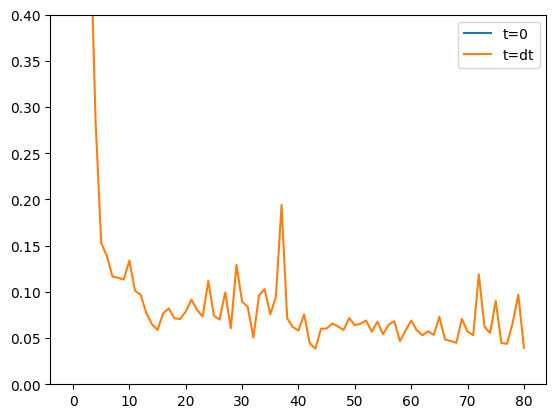

In [31]:
mean_over = 20
t0 = np.array([torch.mean(x).item() for x in loss_t_0])
t0_mean = t0[t0.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

t_dt = np.array([torch.mean(x).item() for x in loss_t_dt])
t_dt_mean = t_dt[t_dt.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

plt.plot(t0_mean, label='t=0')
plt.plot(t_dt_mean, label='t=dt')
plt.legend()
plt.ylim(0.0,.4)
plt.show()

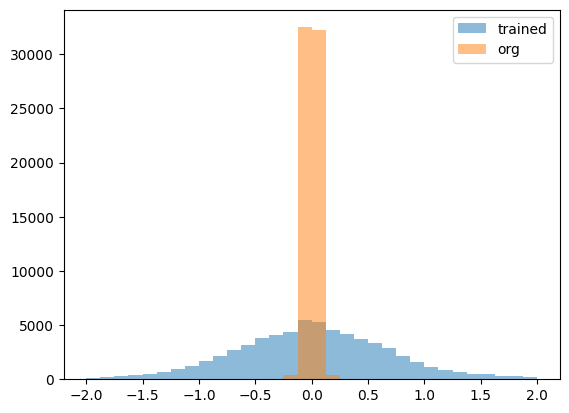

In [32]:
plt.hist(model.edge_params.detach().flatten(), bins=32, label='trained', alpha=0.5,range=(-2,2))
plt.hist((torch.randn(model.edge_params.shape)/20).flatten(), bins=32, label='org', alpha=0.5,range=(-2,2))
plt.legend()
plt.show()

In [33]:
NUM_TEST_STEPS = 64
res_dict = {}

with torch.no_grad():
    for inc_prob in [.05,.1,.2,.5]:
        loss_te_dt = []
        for i in range(NUM_TEST_STEPS):
            sample = get_sample(values,inclusion_prob=0.2)

            y_hat = model(
                sample[0],
                sample[1],
            )

            l_dt = ((sample[2][:,-1] - y_hat[:,-1])**2).T
            loss_te_dt.append(l_dt.detach())
        res_dict[inc_prob] = torch.cat(loss_te_dt).cpu().numpy()

/tmp/ipykernel_449/3835534236.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


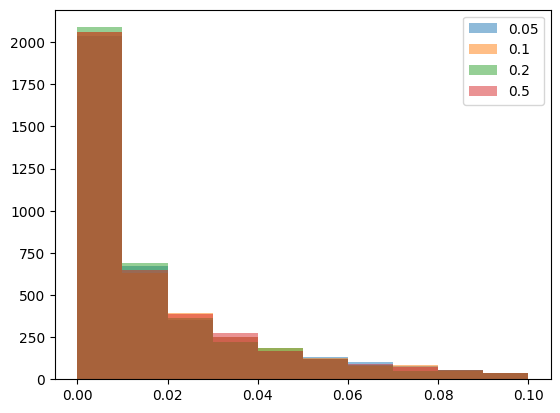

In [34]:
for label, part_res in res_dict.items():
    plt.hist(part_res,range=(0,0.1), alpha=0.5, label=str(label))
plt.legend()
plt.show()

In [36]:
res_dict[0.5].shape

(4096,)